# Fermionic Permutation on 2D Grid (Compressed O(1) Algorithm)

This notebook implements a constant-depth fermionic permutation algorithm on a 2D grid topology.
It uses Hall's decomposition with measurement-based feedforward to perform prefix XORs in O(1) depth.

Refactor goals:
- Keep the custom implementation close to OpenFermion's permutation I/O spec (qubits + permutation).
- Provide a wrapper to choose between the OpenFermion baseline and the custom algorithm.
- Verify correctness on random basis, random pure, and random mixed inputs using statevector or density-matrix simulators.


In [1]:
import cirq
import numpy as np
import networkx as nx
import sympy
from typing import Dict, List, Sequence, Optional, Literal

from openfermion.circuits.gates import FSWAP


## 1. Grid Topology & Utilities

We use raster order for logical indices: `(r, c) -> r * L + c`.
The custom algorithm operates on a 2D grid with interleaved ancillas.


In [2]:
def infer_grid_size(num_data_qubits: int) -> int:
    L = int(np.sqrt(num_data_qubits))
    if L * L != num_data_qubits:
        raise ValueError(f"Custom grid algorithm requires a square number of qubits, got {num_data_qubits}.")
    return L


def validate_permutation(permutation: Sequence[int], n: int) -> None:
    if len(permutation) != n:
        raise ValueError(f"Permutation length {len(permutation)} != {n}.")
    if sorted(permutation) != list(range(n)):
        raise ValueError("Permutation must be a reordering of 0..N-1.")


def snake_order_indices(L: int) -> List[int]:
    order = []
    for r in range(L):
        row = [r * L + c for c in range(L)]
        if r % 2 == 1:
            row.reverse()
        order.extend(row)
    return order


def raster_to_snake_index_map(L: int) -> Dict[int, int]:
    snake = snake_order_indices(L)
    return {r_idx: s_pos for s_pos, r_idx in enumerate(snake)}


def invert_index_map(index_map: Dict[int, int], size: int) -> List[int]:
    inv = [0] * size
    for old, new in index_map.items():
        inv[new] = old
    return inv


def raster_perm_to_snake(L: int, perm_raster: Sequence[int]) -> List[int]:
    r2s = raster_to_snake_index_map(L)
    perm_snake = [0] * (L * L)
    for src_r, dst_r in enumerate(perm_raster):
        perm_snake[r2s[src_r]] = r2s[dst_r]
    return perm_snake


def permute_state_vector(state: np.ndarray, old_to_new: Sequence[int]) -> np.ndarray:
    n = int(np.log2(state.size))
    if len(old_to_new) != n:
        raise ValueError("old_to_new length must match number of qubits.")
    tensor = state.reshape((2,) * n)
    inv = [0] * n
    for old, new in enumerate(old_to_new):
        inv[new] = old
    return np.transpose(tensor, axes=inv).reshape(-1)


def permute_density_matrix(rho: np.ndarray, old_to_new: Sequence[int]) -> np.ndarray:
    n = int(np.log2(rho.shape[0]))
    if len(old_to_new) != n:
        raise ValueError("old_to_new length must match number of qubits.")
    tensor = rho.reshape((2,) * n * 2)
    inv = [0] * n
    for old, new in enumerate(old_to_new):
        inv[new] = old
    axes = inv + [i + n for i in inv]
    return np.transpose(tensor, axes=axes).reshape(rho.shape)


def reorder_state(state: np.ndarray, old_to_new: Sequence[int]) -> np.ndarray:
    if state.ndim == 1:
        return permute_state_vector(state, old_to_new)
    return permute_density_matrix(state, old_to_new)


class GridTopology:
    def __init__(self, L: int, data_qubits: Optional[Sequence[cirq.Qid]] = None,
                 ancilla_qubits: Optional[Sequence[cirq.Qid]] = None):
        self.L = L
        self.data_map: Dict[tuple, cirq.Qid] = {}
        self.ancilla_map: Dict[tuple, cirq.Qid] = {}

        if data_qubits is None:
            # Default: data qubits at (r, 2c)
            for r in range(L):
                for c in range(L):
                    self.data_map[(r, c)] = cirq.GridQubit(r, 2 * c)
        else:
            if len(data_qubits) != L * L:
                raise ValueError("data_qubits must have length L*L.")
            data_qubits = list(data_qubits)
            for r in range(L):
                for c in range(L):
                    self.data_map[(r, c)] = data_qubits[r * L + c]

        if ancilla_qubits is None:
            if data_qubits is None:
                # Default: ancillas between data qubits at (r, 2k+1)
                for r in range(L):
                    for k in range(L - 1):
                        self.ancilla_map[(r, k)] = cirq.GridQubit(r, 2 * k + 1)
            else:
                # Generic ancillas when external data qubits are supplied
                for r in range(L):
                    for k in range(L - 1):
                        self.ancilla_map[(r, k)] = cirq.NamedQubit(f"anc_{r}_{k}")
        else:
            if len(ancilla_qubits) != L * (L - 1):
                raise ValueError("ancilla_qubits must have length L*(L-1).")
            ancilla_qubits = list(ancilla_qubits)
            idx = 0
            for r in range(L):
                for k in range(L - 1):
                    self.ancilla_map[(r, k)] = ancilla_qubits[idx]
                    idx += 1

        self.data_qubits = [self.data_map[(r, c)] for r in range(L) for c in range(L)]
        self.ancilla_qubits = [self.ancilla_map[(r, k)] for r in range(L) for k in range(L - 1)]
        # Keep data qubits first for easier state embedding
        self.all_qubits = self.data_qubits + self.ancilla_qubits

    def get_data_row(self, r: int) -> List[cirq.Qid]:
        return [self.data_map[(r, c)] for c in range(self.L)]

    def get_ancilla_row(self, r: int) -> List[cirq.Qid]:
        return [self.ancilla_map[(r, k)] for k in range(self.L - 1)]

    def get_data_col(self, c: int) -> List[cirq.Qid]:
        return [self.data_map[(r, c)] for r in range(self.L)]


## 2. Hall's Decomposition Logic

Decomposes permutation $\pi$ into $S_1$ (Col), $S_2$ (Row), $S_3$ (Col).


In [3]:
def decompose_permutation(L: int, logical_perm: Sequence[int]):
    # Return s1, s2, s3 schedule dictionaries.
    G = nx.MultiGraph()
    G.add_nodes_from([f"C{i}" for i in range(L)], bipartite=0)
    G.add_nodes_from([f"T{i}" for i in range(L)], bipartite=1)

    edge_keys = []
    for r in range(L):
        for c in range(L):
            curr_idx = r * L + c
            dst_idx = logical_perm[curr_idx]
            target_c, target_r = dst_idx % L, dst_idx // L
            key = G.add_edge(f"C{c}", f"T{target_c}")
            edge_keys.append((f"C{c}", f"T{target_c}", key, curr_idx, target_r))

    matchings, H = [], G.copy()
    for _ in range(L):
        simp_H = nx.Graph(H.edges())
        matching_dict = nx.bipartite.maximum_matching(simp_H, top_nodes=[f"C{i}" for i in range(L)])
        matched_edges = []
        seen = set()
        for u, v in matching_dict.items():
            if (u, v) in seen or (v, u) in seen:
                continue
            seen.add((u, v))
            key = list(H[u][v].keys())[0]
            matched_edges.append((u, v, key))
            H.remove_edge(u, v, key=key)
        matchings.append(matched_edges)

    item_lookup = {(u, v, k): (idx, tr) for u, v, k, idx, tr in edge_keys}
    item_lookup.update({(v, u, k): (idx, tr) for u, v, k, idx, tr in edge_keys})

    temp_s1 = {c: {} for c in range(L)}
    post_s1_loc = {}
    for k, matching in enumerate(matchings):
        for u, v, key in matching:
            info_key = (u, v, key) if u.startswith("C") else (v, u, key)
            item_idx, final_r = item_lookup[info_key]
            c_curr, r_curr = item_idx % L, item_idx // L
            temp_s1[c_curr][r_curr] = k
            post_s1_loc[(k, c_curr)] = (item_idx, final_r)

    s1, s2, s3 = {c: [0] * L for c in range(L)}, {r: [0] * L for r in range(L)}, {c: [0] * L for c in range(L)}
    post_s2_loc = {}

    for c in range(L):
        for r, target in temp_s1[c].items():
            s1[c][r] = target

    for r in range(L):
        for c in range(L):
            if (r, c) in post_s1_loc:
                item_idx, final_r = post_s1_loc[(r, c)]
                real_target = logical_perm[item_idx]
                real_c = real_target % L
                s2[r][c] = real_c
                post_s2_loc[(r, real_c)] = final_r

    for c in range(L):
        for r in range(L):
            if (r, c) in post_s2_loc:
                s3[c][r] = post_s2_loc[(r, c)]

    return s1, s2, s3


## 3. Custom Compressed Fermionic Permutation

The circuit uses measurement-based feedforward. For simulation we explicitly read measurement results
and apply corrections, which keeps the behavior correct for arbitrary inputs (basis, superposition,
or mixed) when comparing reduced data states.

Phase corrections are simplified by canceling duplicate CZ/Z gates, then:
1) apply Z corrections, 2) schedule CZ edges in two non-conflicting rounds, and
3) compile horizontal data-data CZ as nearest-neighbor `CNOT-CZ-CNOT` through the middle ancilla.


In [4]:
class CompressedFermionicPermutation:
    def __init__(self, L: int, data_qubits: Optional[Sequence[cirq.Qid]] = None,
                 ancilla_qubits: Optional[Sequence[cirq.Qid]] = None,
                 topology: Optional[GridTopology] = None):
        self.L = L
        self.topo = topology or GridTopology(L, data_qubits=data_qubits, ancilla_qubits=ancilla_qubits)
        self._data_pos = {q: (r, c) for (r, c), q in self.topo.data_map.items()}
        self._data_index = {q: i for i, q in enumerate(self.topo.data_qubits)}

    def _get_direction(self, round_parity: int, r: int):
        data = self.topo.get_data_row(r)
        anc = self.topo.get_ancilla_row(r)
        if round_parity == 0:  # R->L
            return list(reversed(data)), list(reversed(anc))
        return data, anc  # L->R

    def _build_key(self, t_idx: int, r: int) -> str:
        return f"m_build_t{t_idx}_r{r}"

    def _unbuild_key(self, t_idx: int, r: int) -> str:
        return f"m_unbuild_t{t_idx}_r{r}"

    def build_prefix_xor_moments(self, round_parity: int, t_idx: int) -> List[cirq.Moment]:
        moments = []
        # Init ancillas
        moments.append(cirq.Moment([cirq.reset(a) for a in self.topo.ancilla_qubits]))
        moments.append(cirq.Moment([cirq.H(a) for a in self.topo.ancilla_qubits]))

        # Anc -> Data
        ops = []
        for r in range(self.L):
            Q, A = self._get_direction(round_parity, r)
            for k in range(self.L - 1):
                ops.append(cirq.CNOT(A[k], Q[k + 1]))
        moments.append(cirq.Moment(ops))

        # Data -> Anc
        ops = []
        for r in range(self.L):
            Q, A = self._get_direction(round_parity, r)
            for k in range(self.L - 1):
                ops.append(cirq.CNOT(Q[k], A[k]))
        moments.append(cirq.Moment(ops))

        # Measure Z per row (single multi-bit key)
        ops = []
        for r in range(self.L):
            row_anc = self.topo.get_ancilla_row(r)
            ops.append(cirq.measure(*row_anc, key=self._build_key(t_idx, r)))
        moments.append(cirq.Moment(ops))

        # Classically-controlled prefix corrections
        ops = []
        for r in range(self.L):
            Q, A = self._get_direction(round_parity, r)
            row_anc = self.topo.get_ancilla_row(r)
            phys_index = {a: k for k, a in enumerate(row_anc)}
            key = self._build_key(t_idx, r)
            base = sympy.IndexedBase(key)
            prefix_expr = None
            for k in range(self.L - 1):
                idx = phys_index[A[k]]
                term = base[idx]
                prefix_expr = term if prefix_expr is None else sympy.Xor(prefix_expr, term)
                cond = cirq.SympyCondition(prefix_expr)
                ops.append(cirq.X(Q[k + 1]).with_classical_controls(cond))
        if ops:
            moments.append(cirq.Moment(ops))

        return moments

    def unbuild_prefix_xor_moments(self, round_parity: int, t_idx: int) -> List[cirq.Moment]:
        moments = []

        # Reset
        ops = []
        for r in range(self.L):
            ops.extend([cirq.reset(a) for a in self.topo.get_ancilla_row(r)])
        moments.append(cirq.Moment(ops))

        # Data -> Anc
        ops = []
        for r in range(self.L):
            Q, A = self._get_direction(round_parity, r)
            for k in range(self.L - 1):
                ops.append(cirq.CNOT(Q[k], A[k]))
        moments.append(cirq.Moment(ops))

        # Anc -> Data
        ops = []
        for r in range(self.L):
            Q, A = self._get_direction(round_parity, r)
            for k in range(self.L - 1):
                ops.append(cirq.CNOT(A[k], Q[k + 1]))
        moments.append(cirq.Moment(ops))

        # Measure X (H + Measure per row)
        ops_h = [cirq.H(a) for a in self.topo.ancilla_qubits]
        ops_m = []
        for r in range(self.L):
            row_anc = self.topo.get_ancilla_row(r)
            ops_m.append(cirq.measure(*row_anc, key=self._unbuild_key(t_idx, r)))
        moments.append(cirq.Moment(ops_h))
        moments.append(cirq.Moment(ops_m))

        # Classically-controlled suffix corrections
        ops = []
        for r in range(self.L):
            Q, A = self._get_direction(round_parity, r)
            row_anc = self.topo.get_ancilla_row(r)
            phys_index = {a: k for k, a in enumerate(row_anc)}
            key = self._unbuild_key(t_idx, r)
            base = sympy.IndexedBase(key)
            dir_indices = [phys_index[a] for a in A]
            suffix_expr = None
            for k in range(self.L - 2, -1, -1):
                idx = dir_indices[k]
                term = base[idx]
                suffix_expr = term if suffix_expr is None else sympy.Xor(suffix_expr, term)
                cond = cirq.SympyCondition(suffix_expr)
                ops.append(cirq.Z(Q[k]).with_classical_controls(cond))
        if ops:
            moments.append(cirq.Moment(ops))

        return moments

    def _pair_key(self, q1: cirq.Qid, q2: cirq.Qid):
        i1 = self._data_index.get(q1)
        i2 = self._data_index.get(q2)
        if i1 is not None and i2 is not None:
            return (q1, q2) if i1 < i2 else (q2, q1)
        return (q1, q2) if str(q1) < str(q2) else (q2, q1)

    def get_phase_corrections_moments(self, active_swaps, round_parity: int) -> List[cirq.Moment]:
        cz_counts: Dict[tuple, int] = {}
        z_counts: Dict[cirq.Qid, int] = {}

        def add_cz(a, b):
            key = self._pair_key(a, b)
            cz_counts[key] = cz_counts.get(key, 0) + 1

        def add_z(q):
            z_counts[q] = z_counts.get(q, 0) + 1

        for c in range(self.L):
            for r in active_swaps[c]:
                row_qs = self.topo.get_data_row(r)
                row_qs_next = self.topo.get_data_row(r + 1)
                TL = row_qs[c]
                BL = row_qs_next[c]

                TR = BR = None
                if round_parity == 0 and c < self.L - 1:
                    TR, BR = row_qs[c + 1], row_qs_next[c + 1]
                elif round_parity == 1 and c > 0:
                    TR, BR = row_qs[c - 1], row_qs_next[c - 1]

                add_cz(TL, BL)
                if TR:
                    add_cz(TL, TR)
                    add_z(TR)
                if BR:
                    add_cz(BL, BR)
                    add_z(BR)
                if TR and BR:
                    add_cz(TR, BR)

        z_ops = [cirq.Z(q) for q, cnt in z_counts.items() if cnt % 2 == 1]
        cz_pairs = [pair for pair, cnt in cz_counts.items() if cnt % 2 == 1]

        def split_two_rounds(edges):
            if not edges:
                return [[], []]

            incident = {}
            for idx, (q1, q2) in enumerate(edges):
                incident.setdefault(q1, []).append(idx)
                incident.setdefault(q2, []).append(idx)

            adjacency = {idx: set() for idx in range(len(edges))}
            feasible = True
            for edge_indices in incident.values():
                if len(edge_indices) > 2:
                    feasible = False
                for i in range(len(edge_indices)):
                    for j in range(i + 1, len(edge_indices)):
                        a = edge_indices[i]
                        b = edge_indices[j]
                        adjacency[a].add(b)
                        adjacency[b].add(a)

            color = {}
            for start in range(len(edges)):
                if start in color:
                    continue
                stack = [start]
                color[start] = 0
                while stack:
                    cur = stack.pop()
                    for nxt in adjacency[cur]:
                        if nxt not in color:
                            color[nxt] = 1 - color[cur]
                            stack.append(nxt)
                        elif color[nxt] == color[cur]:
                            feasible = False

            if not feasible:
                return None

            rounds = [[], []]
            for idx, edge in enumerate(edges):
                rounds[color[idx]].append(edge)
            return rounds

        rounds = split_two_rounds(cz_pairs)
        if rounds is None:
            raise ValueError("Phase CZ edges were expected to be 2-round schedulable, but coloring failed.")

        used_horizontal_ancillas = []
        for q1, q2 in cz_pairs:
            p1 = self._data_pos.get(q1)
            p2 = self._data_pos.get(q2)
            if p1 is None or p2 is None:
                continue
            r1, c1 = p1
            r2, c2 = p2
            if r1 == r2 and abs(c1 - c2) == 1:
                used_horizontal_ancillas.append(self.topo.ancilla_map[(r1, min(c1, c2))])

        moments = []
        if used_horizontal_ancillas:
            moments.append(cirq.Moment([cirq.reset(a) for a in used_horizontal_ancillas]))
        if z_ops:
            moments.append(cirq.Moment(z_ops))

        for edges_in_round in rounds:
            vertical_ops = []
            h_cnot_1_ops = []
            h_mid_ops = []
            h_cnot_2_ops = []
            other_ops = []

            for q1, q2 in edges_in_round:
                p1 = self._data_pos.get(q1)
                p2 = self._data_pos.get(q2)
                if p1 is None or p2 is None:
                    other_ops.append(cirq.CZ(q1, q2))
                    continue
                r1, c1 = p1
                r2, c2 = p2

                if c1 == c2:
                    vertical_ops.append(cirq.CZ(q1, q2))
                elif r1 == r2 and abs(c1 - c2) == 1:
                    if c1 < c2:
                        left, right = q1, q2
                    else:
                        left, right = q2, q1
                    anc = self.topo.ancilla_map[(r1, min(c1, c2))]
                    h_cnot_1_ops.append(cirq.CNOT(left, anc))
                    h_mid_ops.append(cirq.CZ(anc, right))
                    h_cnot_2_ops.append(cirq.CNOT(left, anc))
                else:
                    other_ops.append(cirq.CZ(q1, q2))

            if h_cnot_1_ops:
                moments.append(cirq.Moment(h_cnot_1_ops))

            mid_ops = vertical_ops + h_mid_ops + other_ops
            if mid_ops:
                moments.append(cirq.Moment(mid_ops))

            if h_cnot_2_ops:
                moments.append(cirq.Moment(h_cnot_2_ops))

        return moments

    def get_swaps_moments(self, active_swaps) -> List[cirq.Moment]:
        ops = []
        for c in range(self.L):
            col_qs = self.topo.get_data_col(c)
            for r in active_swaps[c]:
                ops.append(cirq.SWAP(col_qs[r], col_qs[r + 1]))
        return [cirq.Moment(ops)]

    def simulate(self, permutation: Sequence[int], data_state: np.ndarray,
                 simulator: Optional[cirq.SimulatesFinalState] = None):
        validate_permutation(permutation, self.L * self.L)

        if simulator is None:
            simulator = cirq.DensityMatrixSimulator() if data_state.ndim == 2 else cirq.Simulator()

        num_data = self.L * self.L
        num_anc = len(self.topo.ancilla_qubits)
        qubit_order = self.topo.all_qubits

        # Embed data state and start with ancillas in |0...0>
        if data_state.ndim == 1:
            anc = np.zeros(2 ** num_anc, dtype=complex)
            anc[0] = 1.0
            initial_state = np.kron(data_state, anc)
        else:
            anc = np.zeros((2 ** num_anc, 2 ** num_anc), dtype=complex)
            anc[0, 0] = 1.0
            initial_state = np.kron(data_state, anc)

        state = simulator.simulate(cirq.Circuit(), qubit_order=qubit_order, initial_state=initial_state)

        def _final_state(trial_result):
            return trial_result.final_density_matrix if hasattr(trial_result, "final_density_matrix") else trial_result.final_state_vector

        def _normalize_state(arr: np.ndarray) -> np.ndarray:
            if arr.ndim == 1:
                norm = np.linalg.norm(arr)
                return arr if norm == 0 else arr / norm
            arr = (arr + arr.conj().T) / 2
            tr = np.trace(arr)
            return arr if tr == 0 else arr / tr

        def run_ops(ops_or_moments):
            nonlocal state
            if not ops_or_moments:
                return
            c = cirq.Circuit(ops_or_moments)
            init = _normalize_state(_final_state(state))
            state = simulator.simulate(c, qubit_order=qubit_order, initial_state=init)

        def run_col_stage(schedule):
            cur_perms = {c: list(schedule[c]) for c in range(self.L)}

            for t in range(self.L):
                active_swaps = {c: [] for c in range(self.L)}
                overall_active = False
                round_parity = t % 2
                start_idx = 1 if round_parity == 1 else 0

                for c in range(self.L):
                    arr = cur_perms[c]
                    for i in range(start_idx, self.L - 1, 2):
                        if arr[i] > arr[i + 1]:
                            active_swaps[c].append(i)
                            overall_active = True

                if not overall_active:
                    if all(cur_perms[c] == sorted(cur_perms[c]) for c in range(self.L)):
                        break
                    continue

                # 1) Build (with classically-controlled corrections)
                run_ops(self.build_prefix_xor_moments(round_parity, t))

                # 2) Phase
                run_ops(self.get_phase_corrections_moments(active_swaps, round_parity))

                # 3) Unbuild (with classically-controlled corrections)
                run_ops(self.unbuild_prefix_xor_moments(round_parity, t))

                # 4) Swap
                run_ops(self.get_swaps_moments(active_swaps))

                # Update classical permutation
                for c in range(self.L):
                    arr = cur_perms[c]
                    for r in active_swaps[c]:
                        arr[r], arr[r + 1] = arr[r + 1], arr[r]

        # Run stages
        s1, s2, s3 = decompose_permutation(self.L, permutation)
        run_col_stage(s1)

        # Row stage using baseline LinearPermutationGate per row
        for r in range(self.L):
            row_qs = self.topo.get_data_row(r)
            row_perm = {i: s2[r][i] for i in range(self.L)}
            run_ops([cirq.contrib.acquaintance.permutation.LinearPermutationGate(self.L, row_perm, FSWAP).on(*row_qs)])

        run_col_stage(s3)

        return _final_state(state), qubit_order


## 4. Baseline-Compatible Wrappers

OpenFermion's internal `_permute` is a thin wrapper around Cirq's `LinearPermutationGate` with `FSWAP`.
We match that I/O spec here and provide a method switcher.

Note: OpenFermion expects a 1D JW order. For a 2D grid we use a snake ordering when comparing
against the baseline (see the verification harness).


In [5]:
def openfermion_permute_ops(qubits: Sequence[cirq.Qid], permutation: Sequence[int]) -> cirq.OP_TREE:
    # Baseline-compatible fermionic permutation (OpenFermion style).
    validate_permutation(permutation, len(qubits))
    return cirq.contrib.acquaintance.permutation.LinearPermutationGate(
        len(qubits), {i: permutation[i] for i in range(len(permutation))}, FSWAP
    ).on(*qubits)


def build_permutation_circuit(qubits: Sequence[cirq.Qid], permutation: Sequence[int],
                              method: Literal["openfermion", "custom"] = "openfermion",
                              **kwargs) -> cirq.Circuit:
    # Return a circuit for the requested method.
    # Note: the custom circuit contains measurements but omits classical corrections.
    if method == "openfermion":
        return cirq.Circuit(openfermion_permute_ops(qubits, permutation))

    if method == "custom":
        L = infer_grid_size(len(qubits))
        program = CompressedFermionicPermutation(L, data_qubits=qubits, **kwargs)
        s1, s2, s3 = decompose_permutation(L, permutation)
        moments = []

        def append_col_stage(schedule):
            cur_perms = {c: list(schedule[c]) for c in range(L)}
            for t in range(L):
                active_swaps = {c: [] for c in range(L)}
                overall_active = False
                round_parity = t % 2
                start_idx = 1 if round_parity == 1 else 0

                for c in range(L):
                    arr = cur_perms[c]
                    for i in range(start_idx, L - 1, 2):
                        if arr[i] > arr[i + 1]:
                            active_swaps[c].append(i)
                            overall_active = True

                if not overall_active:
                    if all(cur_perms[c] == sorted(cur_perms[c]) for c in range(L)):
                        break
                    continue

                moments.extend(program.build_prefix_xor_moments(round_parity, t))
                moments.extend(program.get_phase_corrections_moments(active_swaps, round_parity))
                moments.extend(program.unbuild_prefix_xor_moments(round_parity, t))
                moments.extend(program.get_swaps_moments(active_swaps))

                for c in range(L):
                    arr = cur_perms[c]
                    for r in active_swaps[c]:
                        arr[r], arr[r + 1] = arr[r + 1], arr[r]

        append_col_stage(s1)
        for r in range(L):
            row_qs = program.topo.get_data_row(r)
            row_perm = {i: s2[r][i] for i in range(L)}
            moments.append(cirq.Moment([
                cirq.contrib.acquaintance.permutation.LinearPermutationGate(L, row_perm, FSWAP).on(*row_qs)
            ]))
        append_col_stage(s3)
        return cirq.Circuit(moments)

    raise ValueError(f"Unknown method: {method}")


## 5. Simulation Helpers (Basis / Pure / Mixed)

We compare reduced data density matrices for robustness across inputs.


In [6]:
def random_basis_state(num_qubits: int, rng: np.random.Generator):
    bits = rng.integers(0, 2, size=num_qubits).tolist()
    idx = 0
    for i, b in enumerate(bits):
        if b:
            idx |= 1 << (num_qubits - 1 - i)
    vec = np.zeros(2 ** num_qubits, dtype=complex)
    vec[idx] = 1.0
    return bits, vec


def random_pure_state(num_qubits: int, rng: np.random.Generator) -> np.ndarray:
    dim = 2 ** num_qubits
    vec = rng.normal(size=dim) + 1j * rng.normal(size=dim)
    vec /= np.linalg.norm(vec)
    return vec


def random_mixed_state(num_qubits: int, rng: np.random.Generator, rank: int = 2) -> np.ndarray:
    dim = 2 ** num_qubits
    probs = rng.random(rank)
    probs /= probs.sum()
    rho = np.zeros((dim, dim), dtype=complex)
    for p in probs:
        v = random_pure_state(num_qubits, rng)
        rho += p * np.outer(v, v.conj())
    # Project onto a valid density matrix numerically
    rho = (rho + rho.conj().T) / 2
    rho /= np.trace(rho)
    return rho


def density_matrix_from_state(state: np.ndarray) -> np.ndarray:
    if state.ndim == 1:
        return np.outer(state, state.conj())
    return state


def reduced_density_matrix(state: np.ndarray, num_qubits: int, keep_indices: Sequence[int]) -> np.ndarray:
    dm = density_matrix_from_state(state)
    dims = (2,) * num_qubits
    dm_tensor = dm.reshape(dims + dims)
    reduced = cirq.partial_trace(dm_tensor, keep_indices)
    dim_keep = 2 ** len(keep_indices)
    return reduced.reshape(dim_keep, dim_keep)


def simulate_openfermion(qubits: Sequence[cirq.Qid], permutation: Sequence[int], data_state: np.ndarray,
                          simulator: Optional[cirq.SimulatesFinalState] = None) -> np.ndarray:
    if simulator is None:
        simulator = cirq.DensityMatrixSimulator() if data_state.ndim == 2 else cirq.Simulator()
    circuit = cirq.Circuit(openfermion_permute_ops(qubits, permutation))
    result = simulator.simulate(circuit, qubit_order=qubits, initial_state=data_state)
    return result.final_density_matrix if hasattr(result, "final_density_matrix") else result.final_state_vector


## 6. Verification Harness

Run randomized checks against the OpenFermion baseline for basis, pure, and mixed inputs.


In [7]:
def verify_against_baseline(L: int = 3, trials: int = 5,
                            input_kind: Literal["basis", "pure", "mixed"] = "basis",
                            simulator_kind: Literal["statevector", "density"] = "statevector",
                            seed: int = 0,
                            atol: float = 1e-6) -> None:
    rng = np.random.default_rng(seed)

    custom = CompressedFermionicPermutation(L)
    data_qubits = custom.topo.data_qubits
    num_data = L * L

    # Baseline uses a 1D JW order. We map raster -> snake for comparison.
    snake = snake_order_indices(L)
    r2s = raster_to_snake_index_map(L)
    r2s_list = [r2s[i] for i in range(num_data)]
    s2r = invert_index_map(r2s, num_data)
    data_qubits_snake = [data_qubits[i] for i in snake]

    print()
    print(f"--- Verifying L={L}, input={input_kind}, sim={simulator_kind} ---")

    for t in range(trials):
        perm_raster = list(range(num_data))
        rng.shuffle(perm_raster)
        perm_snake = raster_perm_to_snake(L, perm_raster)

        if input_kind == "basis":
            bits, data_state = random_basis_state(num_data, rng)
        elif input_kind == "pure":
            bits, data_state = None, random_pure_state(num_data, rng)
        elif input_kind == "mixed":
            bits, data_state = None, random_mixed_state(num_data, rng)
        else:
            raise ValueError("Unknown input_kind")

        if simulator_kind == "density" or input_kind == "mixed":
            sim_base = cirq.DensityMatrixSimulator()
            sim_custom = cirq.DensityMatrixSimulator()
        else:
            sim_base = cirq.Simulator()
            sim_custom = cirq.Simulator()

        # Baseline (OpenFermion) in snake order
        data_state_snake = reorder_state(data_state, r2s_list)
        base_state_snake = simulate_openfermion(data_qubits_snake, perm_snake, data_state_snake, simulator=sim_base)
        base_state_raster = reorder_state(base_state_snake, s2r)
        base_rho = density_matrix_from_state(base_state_raster)

        # Custom (compressed feedforward) in raster order
        custom_state, qubit_order = custom.simulate(perm_raster, data_state, simulator=sim_custom)
        custom_rho = reduced_density_matrix(custom_state, len(qubit_order), keep_indices=list(range(num_data)))

        ok = np.allclose(custom_rho, base_rho, atol=atol)
        status = "SUCCESS" if ok else "FAILURE"
        print(f"Trial {t+1}: {status}")
        if not ok:
            print(f"  Perm (raster): {perm_raster}")
            if bits is not None:
                print(f"  Input bits: {bits}")
            break


# Example runs
verify_against_baseline(L=2, trials=5, input_kind="basis", simulator_kind="statevector", seed=1)
verify_against_baseline(L=2, trials=3, input_kind="pure", simulator_kind="statevector", seed=2)
verify_against_baseline(L=2, trials=3, input_kind="mixed", simulator_kind="density", seed=3)

verify_against_baseline(L=3, trials=5, input_kind="basis", simulator_kind="statevector", seed=1)
verify_against_baseline(L=3, trials=3, input_kind="pure", simulator_kind="statevector", seed=2)
# verify_against_baseline(L=3, trials=3, input_kind="mixed", simulator_kind="density", seed=3)



--- Verifying L=2, input=basis, sim=statevector ---
Trial 1: SUCCESS
Trial 2: SUCCESS
Trial 3: SUCCESS
Trial 4: SUCCESS
Trial 5: SUCCESS

--- Verifying L=2, input=pure, sim=statevector ---
Trial 1: SUCCESS
Trial 2: SUCCESS
Trial 3: SUCCESS

--- Verifying L=2, input=mixed, sim=density ---
Trial 1: SUCCESS
Trial 2: SUCCESS
Trial 3: SUCCESS

--- Verifying L=3, input=basis, sim=statevector ---
Trial 1: SUCCESS
Trial 2: SUCCESS
Trial 3: SUCCESS
Trial 4: SUCCESS
Trial 5: SUCCESS

--- Verifying L=3, input=pure, sim=statevector ---
Trial 1: SUCCESS
Trial 2: SUCCESS
Trial 3: SUCCESS


## 7. Visualization Demo

Use the `visualize_fermionic` module to generate step-by-step frames of the algorithm for a specific permutation.


In [8]:
try:
    from visualize_fermionic import visualize_permutation

    # Example: 5x5 Transpose
    L = 5
    perm_list = []
    # Transpose mapping: (r, c) -> (c, r)
    # Indices: r*L + c -> c*L + r
    for r in range(L):
        for c in range(L):
            perm_list.append(c * L + r)

    output_dir = "visualization_demo_{}x{}".format(L, L)
    visualize_permutation(L, perm_list, output_dir)

    print(f"Check '{output_dir}' for generated images.")

except ImportError:
    print("Visualization module 'visualize_fermionic.py' not found.")


Visualizing 5x5 permutation in 'visualization_demo_5x5'...
Generated frame 0/41
Generated frame 5/41
Generated frame 10/41
Generated frame 15/41
Generated frame 20/41
Generated frame 25/41
Generated frame 30/41
Generated frame 35/41
Generated frame 40/41
Visualization complete! Frames saved to visualization_demo_5x5
Check 'visualization_demo_5x5' for generated images.


## 8. Resource Estimation (Lambda-Free Weighted Metric)

This section emphasizes a lambda-free weighted event metric based on exact gate counting:

`weighted_count_metric = CNOT_EQ_TWOQ + measurement_event_count + idle_multiplier * idle_cnot_time`
`idle_cnot_time = measurement_event_count * measurement_duration_mu`

Conventions used here:
- `measurement_event_count` includes both measure and reset events (when enabled).
- `idle_multiplier` defaults to `0.01` and is configurable.
- Exact counting is attempted first with CSV caching/resume.
- If runtime cap is reached, remaining points are extrapolated from exact scaling fits and marked in `result_origin`.

Sweep range in this section: `L = 20, 25, 30, 35, 40, 45, 50`.


,method,L,weighted_count_metric,weighted_cnot_component,weighted_meas_component,weighted_idle_component,CNOT_EQ_TWOQ,measurement_event_count,idle_cnot_time,result_origin
0,baseline_openfermion_snake,20,80172.00,80172.0,0.0,0.00,80172.0,0.0,0.0,exact
1,custom_ancilla_row_cnot,20,124181.38,95035.0,28120.0,1026.38,95035.0,28120.0,102638.0,exact
2,baseline_openfermion_snake,25,201166.00,201166.0,0.0,0.00,201166.0,0.0,0.0,exact
3,custom_ancilla_row_cnot,25,244998.80,187784.0,55200.0,2014.80,187784.0,55200.0,201480.0,exact
4,baseline_openfermion_snake,30,400760.00,400760.0,0.0,0.00,400760.0,0.0,0.0,exact
5,custom_ancilla_row_cnot,30,431079.07,328279.0,99180.0,3620.07,328279.0,99180.0,362007.0,exact
6,baseline_openfermion_snake,35,751692.00,751692.0,0.0,0.00,751692.0,0.0,0.0,exact
7,custom_ancilla_row_cnot,35,696974.29,531694.0,159460.0,5820.29,531694.0,159460.0,582029.0,exact
8,baseline_openfermion_snake,40,1245116.00,1245116.0,0.0,0.00,1245116.0,0.0,0.0,exact
9,custom_ancilla_row_cnot,40,1034804.88,789030.0,237120.0,8654.88,789030.0,237120.0,865488.0,exact


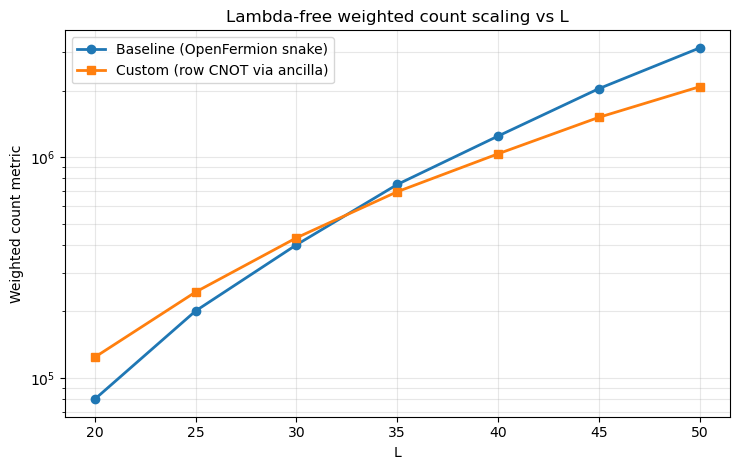

In [9]:
from resource_estimation import (
    run_weighted_metric_study_with_cache,
    plot_fidelity_scaling,
    run_and_plot_resource_estimation,
)
from IPython.display import display
import matplotlib.pyplot as plt

# Primary metric: lambda-free weighted event count
L_values = list(range(20, 51, 5))
weighted_df = run_weighted_metric_study_with_cache(
    L_values=L_values,
    permutation_kind="random",
    seed=7,
    include_reset_as_measurement=False,
    measurement_duration_mu=3.65,
    idle_multiplier=0.01,
    other_2q_cnot_equivalent=1.0,
    max_runtime_minutes=90.0,
    cache_csv_path="resource_estimation_cache.csv",
)

display_cols = [
    "method",
    "L",
    "weighted_count_metric",
    "weighted_cnot_component",
    "weighted_meas_component",
    "weighted_idle_component",
    "CNOT_EQ_TWOQ",
    "measurement_event_count",
    "idle_cnot_time",
    "result_origin",
]

display(weighted_df[display_cols])
fig_w, ax_w = plot_fidelity_scaling(weighted_df, metric="weighted_count_metric")
plt.show()

# Secondary (optional) old metrics from exact resource estimator:
# summary_df, fig_prod, ax_prod = run_and_plot_resource_estimation(
#     L_values=L_values,
#     permutation_kind="random",
#     seed=7,
#     single_qubit_error=1e-3,
#     two_qubit_error=1e-4,
#     measurement_error=1e-4,
#     idle_error=1e-6,
#     idle_multiplier=0.01,
#     include_single_qubit_in_estimation=False,
#     measurement_duration_mu=3.65,
#     include_reset_as_measurement=True,
#     plot_metric="success_probability",
# )
# fig_sum, ax_sum = plot_fidelity_scaling(summary_df, metric="error_sum_total")
# plt.show()
